# Получение информации по поверке средств измерения в системе "Аршин" через API

Данный гайд показывает как можно получить информацию из системы "Аршин" и проверить информацию по поверке средств измерения используя стандартные библиотеки для работы с данными. Система имеет OEI-API.

OEI-API (Application Programming Interface) - программный интерфейс, предназначенный для предоставления в автоматическом режиме сведений о результатах поверок СИ, содержащихся в Федеральном информационном фонде по обеспечению единства измерений.

API обеспечивает возможность формирования и передачу запроса, и последующее получение результатов запроса в формате JSON. Данная возможность обеспечивается путем предоставления доступа к синхронным интерфейсам с использованием протокола HTTP 1.1.

## Ограничения на этапе тестирования и отладки:

* Выдача ограничена 10000 записей за 1 запрос (LIMIT 10000), планируется отдавать до 3млн. записей
* Вывод данных возможен в виде php array, json или xml. Устанавливается параметром &export_type (1 - php array; 2 - json; 3 - xml)
* Принудительное время выполнения скрипта ограничено 5 минутами. Оптимизируйте запрос под Ваши потребности.
* Планируется возвращение данных в виде сжатого массива
* Регистр при вводе параметр значеняи не имеет
* Все параметры (кроме ?regkey=d37e5f9c2df49556a580b1c3dc8dcc7a), указанные ниже, являются необязательными. Допустимы любые их комбиации
* Параметр regkey=d37e5f9c2df49556a580b1c3dc8dcc7a - ключ доступа для тестирования и отладки. Полноценный рабочий regkey предоставляется бонусом при приобретении годовой подписки на аналитику и будет доступен в профиле пользователя.

Подключим необходимые модули

In [1]:
import pandas as pd
import requests

Зададим точку входа для получения данных

In [2]:
url = 'http://731163-cj72200.tmweb.ru/vri/'

Проверим, что система "Аршин" нам отвечает

In [3]:
r = requests.get(url)
r

<Response [200]>

## Параметры запроса
&export_type - тип выходного массива данных.
1 - php array; 2 - json (для кодирования использована стандартаня PHP функция json_encode(), для декодирования следует использовать json_decode()); 3 - xml. Пример вывода данных в xml формате
http://731163-cj72200.tmweb.ru/vri/?regkey=d37e5f9c2df49556a580b1c3dc8dcc7a&vri_id_from=147222222&vri_id_to=147222322&export_type=3

&vri_id - id поверки.
Число в конце ccылки на карточку поверки в ФГИС АРШИН. Например для поверки https://fgis.gost.ru/fundmetrology/cm/results/1-179725564 это число 179725564

&vri_id_from - id поверки от.
Нижняя граница для поиска поверок по id. Например, при &vri_id_from=12345 будут выводиться только те поверки, чей id больше или равен 12345

&vri_id_to - id поверки до.
Верхняя граница для поиска поверок по id. Например, при &vri_id_to=99999 будут выводиться только те поверки, чей id меньше или равен 99999

&mi_number - Заводской номер СИ.
Текствое поле. Ищется строгое совпадение. Например, для поиска заводсого номера '05359326' необходимо задать &mi_number=05359326

&mi_modification - Модификация СИ.
Текствое поле. Ищется строгое совпадение. Например, для поиска модификации СИ 'Меркурий 230 ART-03 PQRSIDN' необходимо задать &mi_modification=Меркурий 230 ART-03 PQRSIDN

&mitypeTitle - Наименование СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска наименования СИ 'Счетчики электрической энергии трёхфазные статические' можно задать &mitypeTitle=электрической энергии

&mit_MPISI - Межповерочный интервал в соотвествии с ОТ.
Текствое поле. Можно указывать часть фразы. Например, для поиска такой фразы '4 года - для гор.воды; 6 лет - хол.' можно задать &mit_MPISI=6 лет - хол

&mit_id - id типа СИ в реестре СИ АРШИН.
Поле типа int. Ищется полное совпадение. Например: &mit_id=347162

&mitypeType - Обозначение типа СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска обозначения типа СИ 'Меркурий 230' можно задать &mitypeType=меркурий

&mitypeNumber - № типа СИ в госреестре.
Текствое поле. Ищется полное совпадение. Например: &mitypeNumber=23345-07

&org_title - Наименование организации-поверителя.
Текствое поле. Можно указывать часть фразы. Например, для поиска организации 'ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ЭНЕРТЕСТ(ООО ЭНЕРТЕСТ)' можно задать &org_title=энертест

&mi_manufactureYear - Год выпуска СИ.
Целое число. Ищется полное совпадение. Например: &mi_manufactureYear=2009

&mi_signCipher - Условный шифр знака поверки.
Текстовое поле. Ищется полное совпадение. Например: &mi_signCipher=ГЦН

&docTitle - Наиенование методики поверки
Текстовое поле. Можно указывать часть фразы. Например, для документа ГОСТ OIML R 76-1-2011: &docTitle=ГОСТ OIML R 76

&mi_Owner_name - Владелец СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска организации 'ООО Газпром трансгаз Ухта' можно задать &mi_Owner_name=ООО Газпром

&mit_owner_CountrySI - Страна производства.
Текстовое поле. Ищется полное совпадение. Например: &mit_owner_CountrySI=россия

&mit_owner_SettlementSI - Населенный пункт (производства).
Текствое поле. Можно указывать часть слова или словосочетания. Например, для поиска СИ, произведенных в Москве: &mit_owner_SettlementSI=моск

&mit_owner_ManufacturerSI - Производитель СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска организации 'ООО Спутник' достаточно задать &mit_owner_ManufacturerSI=Спутник

&poverka_valid_date - Поверка действительна до
Текствое поле. Указывается дата окончания поверки в формате d.m.Y (например - &poverka_valid_date=17.05.2021). Ищется полное совпадение.

&poverka_publication_date - Дата публикации.
Текствое поле. Указывается дата публикации в формате d.m.Y (например - &poverka_publication_date=17.05.2021). Ищется полное совпадение.

&poverka_verification_date - Дата поверки.
Текствое поле. Указывается дата поверки в формате d.m.Y (например - &poverka_verification_date=12.03.2020). Ищется полное совпадение.

&poverka_verification_month - Месяц поверки.
Текствое поле. Указывается месяц поверки с годом в формате m.Y (например - &poverka_verification_month=03.2020). Ищется полное совпадение.

&poverka_verification_year - Год поверки.
Текствое поле. Указывается год в формате Y (например - &poverka_verification_year=2020). Ищется полное совпадение.

&poverka_vriType - Тип поверки.
Числовое поле. 2 - периодическая; 1 - первичная; Например, при такой записи - &poverka_vriType=2 будут отображены только периодические поверки.

# Практическое задания
* Попробуйте получить данные о манометрах, поверенных в ЦАГИ имени Н.Е. Жуковского
* Проверьте есть ли в МАИ поверенные расходомеры
* Проверьте свой домашний счетчик воды (горячей или холодной) на наличие поверки, если конечно счетчик у вас установлен &#x1F600; и он был поверен после 24.09.2020 года (именно с этой даты все организации обязаны передавать данные о поверке в единую систему).

Все данные по п.1/2 обработайте и сведите в Pandas Dataframe в формат удобный для датасета по оценке запросов на поверку средств измерения

Постройте аналитику по полученным данным.

In [4]:
def search(device_name, organisation_name):

  url = 'http://731163-cj72200.tmweb.ru/vri/'

  request_params = {
      'regkey': 'd37e5f9c2df49556a580b1c3dc8dcc7a',
      'mi_Owner_name': organisation_name,
      #'poverka_verification_year': '2024',
      'export_type': '2',
      'mitypeTitle': device_name,
      # 'org_title': organisation_name,
  }

    
  r = requests.get(url, params=request_params)

  print(f'Response status: {r.status_code}')
  print(f'Body: {r.text[:300]}')

  try:
    data = r.json()
  except Exception as e:
    print(f'JsonError: {e}')
    print(f'Response: {r.text[:300]}')
    data = []

  if not data:
    print('Empty')
  else:
    df = pd.DataFrame(data)
    print(f"DataFrame length: {len(df)}")
    return df



In [6]:
df_cagi = search("манометр", "ЦАГИ")

Response status: 200
Body: 
[{"id":1,"vri_id":"634424","mi_number":"076","mi_modification":"\u0414\u041c-01...","mi_manufactureYear":null,"mi_signCipher":"\u0410\u041e\u041b","mi_Owner_name":"\u0424\u0413\u0423\u041f ...","org_title":"\u0424\u0415\u0414\u0415\u0420...","fsa_ral_regNumbers_regNumber":"\u0420\u041e\u0421\u0421 
DataFrame length: 1945


In [7]:
df_mai = search("расходомер", "МАИ")

Response status: 200
Body: 
[{"id":1,"vri_id":"427990506","mi_number":"M1520...","mi_modification":"EL-FLOW","mi_manufactureYear":"2015","mi_signCipher":"\u0414\u0428\u041b","mi_Owner_name":"\u041d\u0418\u0418 \u041f...","org_title":"\u041e\u0411\u0429\u0415\u0421...","fsa_ral_regNumbers_regNumber":"RA.RU...","mitypeNumber":"
DataFrame length: 21


In [30]:
df_cagi['source'] = 'ЦАГИ'
df_mai['source'] = 'МАИ'
combined = pd.concat([df_cagi, df_mai], ignore_index=True)

cols = ['vri_id','mi_number','mi_modification','mi_manufactureYear',
        'mitypeTitle','org_title','mi_Owner_name','vriType',
        'result_doc_type','poverka_valid_date',
        'poverka_verification_year','mit_owner_CountrySI','source']

cols_present = [c for c in cols if c in combined.columns]
dataset = combined[cols_present].copy()


In [31]:
dataset["source"].value_counts()

source
ЦАГИ    1945
МАИ       21
Name: count, dtype: int64

In [32]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1966 entries, 0 to 1965
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   vri_id               1966 non-null   str  
 1   mi_number            1966 non-null   str  
 2   mi_modification      1966 non-null   str  
 3   mi_manufactureYear   66 non-null     str  
 4   mitypeTitle          1966 non-null   str  
 5   org_title            1966 non-null   str  
 6   mi_Owner_name        1966 non-null   str  
 7   vriType              1966 non-null   str  
 8   result_doc_type      1966 non-null   str  
 9   mit_owner_CountrySI  1966 non-null   str  
 10  source               1966 non-null   str  
dtypes: str(11)
memory usage: 169.1 KB


# Аналитика

In [33]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

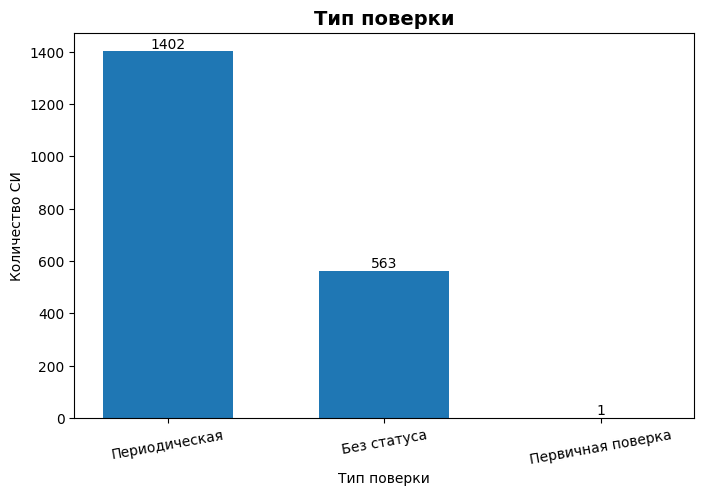

In [34]:
plt.figure(figsize=(8, 5))

vri_type_counts = dataset['vriType'].value_counts()
bars = plt.bar(
    vri_type_counts.index,
    vri_type_counts.values,
    width=0.6
)

plt.bar_label(bars, fontsize=10)
plt.title('Тип поверки', fontsize=14, fontweight='bold')
plt.xlabel('Тип поверки')
plt.ylabel('Количество СИ')
plt.xticks(rotation=10)
plt.show()

In [35]:
print("Статус поверки:")
print(dataset['result_doc_type'].value_counts())

Статус поверки:
result_doc_type
Извещение о непригодности    1966
Name: count, dtype: int64


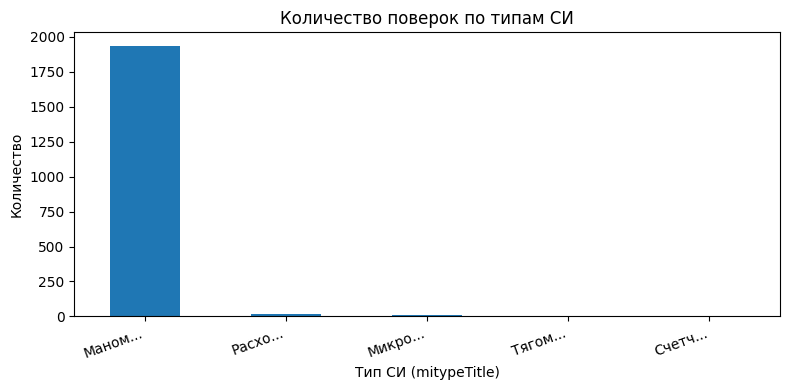

In [36]:
plt.figure(figsize=(8, 4))

dataset['mitypeTitle'].value_counts().plot(kind='bar')

plt.title('Количество поверок по типам СИ')
plt.xlabel('Тип СИ (mitypeTitle)')
plt.ylabel('Количество')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [37]:
dataset['mitypeTitle'].value_counts()

mitypeTitle
Маном...    1936
Расхо...      20
Микро...       7
Тягом...       2
Счетч...       1
Name: count, dtype: int64

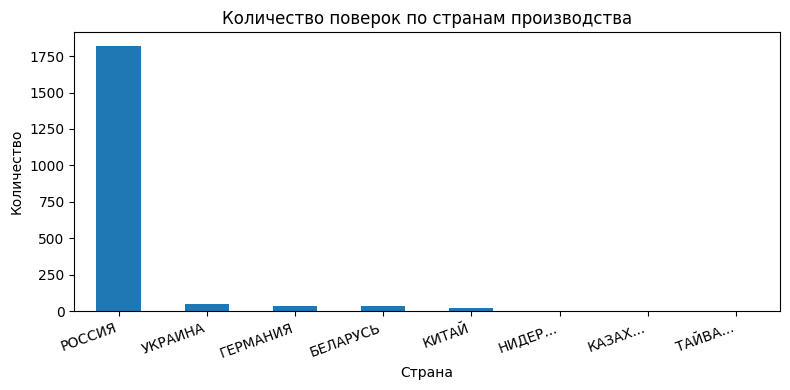

In [38]:
plt.figure(figsize=(8, 4))

dataset['mit_owner_CountrySI'].value_counts().plot(
    kind='bar',
)

plt.title('Количество поверок по странам производства')
plt.xlabel('Страна')
plt.ylabel('Количество')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

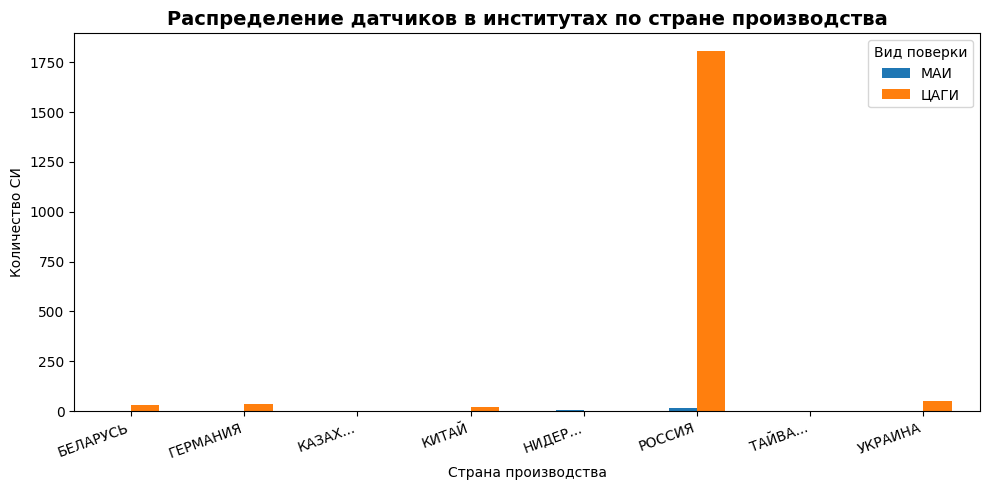

In [39]:
plt.figure(figsize=(10, 5))

cross = (
    dataset.groupby(['mit_owner_CountrySI', 'source'])
    .size()
    .unstack(fill_value=0)
)

cross.plot(
    kind='bar',
    figsize=(10, 5),
)

plt.title('Распределение датчиков в институтах по стране производства', fontsize=14, fontweight='bold')
plt.xlabel('Страна производства')
plt.ylabel('Количество СИ')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Вид поверки')
plt.tight_layout()
plt.show()